# 2D

k_eff = 0.4255962892867037


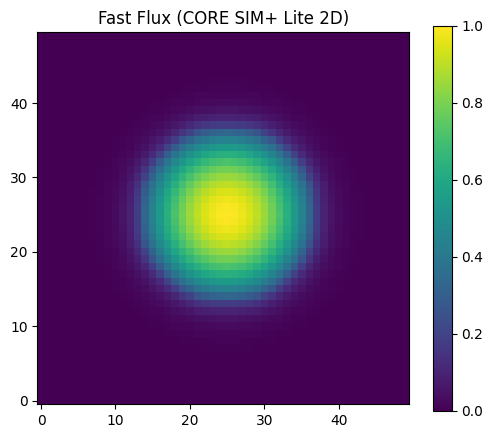

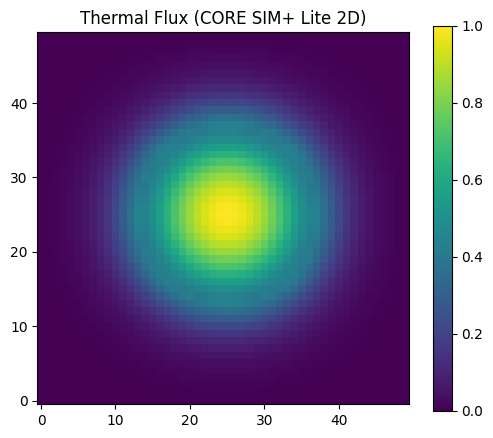

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

# ============================================================
# GEOMETRY
# ============================================================

Nx, Ny = 50, 50
N = Nx * Ny

Lx, Ly = 100.0, 100.0
dx = Lx / (Nx - 1)
dy = Ly / (Ny - 1)

cx = 1.0 / (dx * dx)
cy = 1.0 / (dy * dy)

# index mapping
def idx(i, j):
    return i + j * Nx

# group indexing
def g1(p): return p
def g2(p): return N + p

# ============================================================
# MATERIAL MODEL (FUEL / REFLECTOR)
# ============================================================

def get_material(i, j):

    cx0, cy0 = Nx // 2, Ny // 2
    r = np.sqrt((i - cx0)**2 + (j - cy0)**2)

    if r < 12.0:
        return {
            "D1": 1.5, "D2": 0.4,
            "Sa1": 0.01, "Sa2": 0.04,
            "S12": 0.08,
            "nuf1": 0.006,
            "nuf2": 0.12
        }
    else:
        return {
            "D1": 1.2, "D2": 0.3,
            "Sa1": 0.002, "Sa2": 0.01,
            "S12": 0.10,
            "nuf1": 0.0,
            "nuf2": 0.0
        }

# ============================================================
# SYSTEM MATRICES
# ============================================================

A = lil_matrix((2 * N, 2 * N))
F = lil_matrix((2 * N, 2 * N))

# ============================================================
# BUILD OPERATOR
# ============================================================

for j in range(Ny):
    for i in range(Nx):

        p = idx(i, j)

        m = get_material(i, j)

        D1 = float(m["D1"])
        D2 = float(m["D2"])
        Sa1 = float(m["Sa1"])
        Sa2 = float(m["Sa2"])
        S12 = float(m["S12"])
        nuf1 = float(m["nuf1"])
        nuf2 = float(m["nuf2"])

        gp = g1(p)
        gt = g2(p)

        # ====================================================
        # BOUNDARY CONDITIONS (VACUUM)
        # ====================================================

        if i == 0 or i == Nx - 1 or j == 0 or j == Ny - 1:
            A[gp, gp] = 1.0
            A[gt, gt] = 1.0
            continue

        # ====================================================
        # FAST GROUP
        # ====================================================

        A[gp, g1(idx(i-1, j))] = -D1 * cx
        A[gp, g1(idx(i+1, j))] = -D1 * cx
        A[gp, g1(idx(i, j-1))] = -D1 * cy
        A[gp, g1(idx(i, j+1))] = -D1 * cy

        A[gp, gp] = 2 * D1 * (cx + cy) + Sa1 + S12

        # ====================================================
        # THERMAL GROUP
        # ====================================================

        A[gt, g2(idx(i-1, j))] = -D2 * cx
        A[gt, g2(idx(i+1, j))] = -D2 * cx
        A[gt, g2(idx(i, j-1))] = -D2 * cy
        A[gt, g2(idx(i, j+1))] = -D2 * cy

        A[gt, gt] = 2 * D2 * (cx + cy) + Sa2

        # scattering FAST → THERMAL
        A[gt, gp] = -S12

        # ====================================================
        # FISSION SOURCE
        # ====================================================

        F[gp, gp] += nuf1
        F[gp, gt] += nuf2

# convert
A = csr_matrix(A)
F = csr_matrix(F)

# ============================================================
# POWER ITERATION SOLVER
# ============================================================

phi = np.ones(2 * N)
phi /= np.linalg.norm(phi)

k = 1.0

for it in range(100):

    src = F @ phi

    phi_new = spsolve(A, src)

    k_new = np.sum(src) / np.sum(F @ phi_new)

    phi_new /= np.linalg.norm(phi_new)

    if abs(k_new - k) < 1e-8:
        phi = phi_new
        k = k_new
        break

    phi = phi_new
    k = k_new

print("k_eff =", k)

# ============================================================
# POST PROCESSING
# ============================================================

phi_fast = phi[:N].reshape((Ny, Nx))
phi_thermal = phi[N:].reshape((Ny, Nx))

phi_fast /= np.max(phi_fast)
phi_thermal /= np.max(phi_thermal)

# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(6,5))
plt.imshow(phi_fast, origin="lower")
plt.colorbar()
plt.title("Fast Flux (CORE SIM+ Lite 2D)")
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(phi_thermal, origin="lower")
plt.colorbar()
plt.title("Thermal Flux (CORE SIM+ Lite 2D)")
plt.show()